In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from model import create_model


In [2]:
base_path='.'

In [3]:
(training_x, _), (test_x, _) = mnist.load_data()
(len, height, width) = training_x.shape
training_x = np.reshape(training_x, (len, height, width, 1))
training_x = training_x/255.0

(len, height, width) = test_x.shape
test_x = np.reshape(test_x, (len, height, width, 1))
test_x = test_x / 255.0

In [4]:
training_noise = np.random.normal(loc=0.5, scale=0.5, size=training_x.shape)
test_noise = np.random.normal(loc=0.5, scale=0.5, size=test_x.shape)

In [5]:
training_x_noise = np.clip(training_x + training_noise, 0, 1)
test_x_noise = np.clip(test_x + test_noise, 0, 1)

In [6]:
(encoder, decoder, autoencoder) = create_model(height, width, 1, (16, 32), 16)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

tensorboard = tf.keras.callbacks.TensorBoard(log_dir=base_path + '/logs')
H = autoencoder.fit(training_x_noise, training_x, validation_data=(test_x_noise, test_x), epochs=2, batch_size=256, callbacks=[tensorboard])

Encoder...
Decoder...


/var/folders/p2/2ptx4x1d0fg58ffrcqrmwfsm0000gn/T/ipykernel_21395/868847041.py:1: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  (encoder, decoder, autoencoder) = create_model(height, width, 1, (16, 32), 16)


Epoch 1/2
235/235 ━━━━━━━━━━━━━━━━━━━━ 81s 334ms/step - accuracy: 0.7958 - loss: 0.3258 - val_accuracy: 0.7953 - val_loss: 0.2283
Epoch 2/2
235/235 ━━━━━━━━━━━━━━━━━━━━ 80s 342ms/step - accuracy: 0.7959 - loss: 0.2065 - val_accuracy: 0.8010 - val_loss: 0.1650


In [7]:
predictions = autoencoder.predict(test_x_noise)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


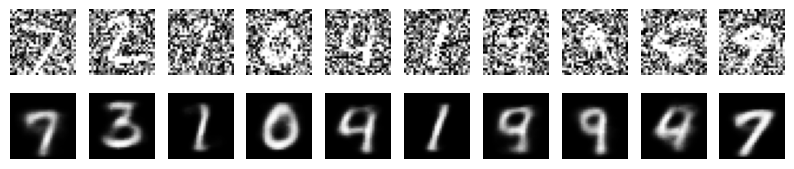

In [8]:
import matplotlib.pyplot as plt

(fig, ax) = plt.subplots(2, 10, figsize=(10, 2))
ax = ax.flatten()
n=10
plt.gray()
for i in range(n):
    ax[i].imshow(test_x_noise[i])
    ax[i].axis('off')
    
    ax[i+n].imshow(predictions[i])
    ax[i+n].axis('off')
plt.show()
    